In [3]:
import sys
sys.path.append('..')
import os

os.environ["BLIS_NUM_THREADS"] = "8"
os.environ["OMP_NUM_THREADS"]  = "8"

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


In [4]:
import os
import psutil

physical_cores = psutil.cpu_count(logical=False)  # real cores
logical_cores  = psutil.cpu_count(logical=True)   # includes hyperthreading

print(f"Physical cores: {physical_cores}")
print(f"Logical  cores: {logical_cores}")

Physical cores: 128
Logical  cores: 128


In [2]:
!free -h

              total        used        free      shared  buff/cache   available
Mem:          251Gi        12Gi       112Gi       138Mi       126Gi       237Gi
Swap:         124Gi       146Mi       124Gi


In [5]:
ratings = pd.read_csv(
	"../ml1m/ratings.dat",
	sep="::",
	names=["user_id", "movie_id", "rating", "timestamp"],
	encoding="latin-1",
	engine="python"
)

movies = pd.read_csv(
	"../ml1m/movies.dat",
	sep="::",
	names=["movie_id", "title", "genres"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)
users = pd.read_csv(
	"../ml1m/users.dat",
	sep="::",
	names=["user_id", "gender", "age","occupation","zip_code"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)

In [6]:
movies.head(),ratings.head(),users.head()

(   movie_id                               title                        genres
 0         1                    Toy Story (1995)   Animation|Children's|Comedy
 1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2         3             Grumpier Old Men (1995)                Comedy|Romance
 3         4            Waiting to Exhale (1995)                  Comedy|Drama
 4         5  Father of the Bride Part II (1995)                        Comedy,
    user_id  movie_id  rating  timestamp
 0        1      1193       5  978300760
 1        1       661       3  978302109
 2        1       914       3  978301968
 3        1      3408       4  978300275
 4        1      2355       5  978824291,
    user_id gender  age  occupation zip_code
 0        1      F    1          10    48067
 1        2      M   56          16    70072
 2        3      M   25          15    55117
 3        4      M   45           7    02460
 4        5      M   25          20    55455)

In [7]:
len(movies),len(ratings),len(users),len(users)*len(movies)

(3883, 1000209, 6040, 23453320)

In [8]:
ratings=ratings.sort_values(by='timestamp')
ratings.head(),len(ratings)

(         user_id  movie_id  rating  timestamp
 1000138     6040       858       4  956703932
 999873      6040       593       5  956703954
 1000153     6040      2384       4  956703954
 1000007     6040      1961       4  956703977
 1000192     6040      2019       5  956703977,
 1000209)

In [9]:
def temporal_sort(ratings):
	ratings=ratings.sort_values(by="timestamp")
	return ratings

In [10]:
def sort(df,col_list):
    df=df.sort_values(by=col_list)
    return df
sort(ratings,["user_id","timestamp"])

,user_id,movie_id,rating,timestamp
31,1,3186,4,978300019
37,1,1022,5,978300055
27,1,1721,4,978300055
22,1,1270,5,978300055
24,1,2340,3,978300103
...,...,...,...,...
1000019,6040,2917,4,997454429
1000172,6040,1784,3,997454464
999988,6040,1921,4,997454464
1000167,6040,161,3,997454486


In [11]:
def train_val_test_split(data,split_distribution=[0.7,0.15,0.15]):
	n=len(data)
	train_percentage,val_percentage,test_percentage=split_distribution[0],split_distribution[1],split_distribution[2]
	train_split_idx,val_split_idx=int(train_percentage*n),int((train_percentage+val_percentage)*n)
	x_train,x_val,x_test=data[:train_split_idx],data[train_split_idx:val_split_idx],data[val_split_idx:]
	return x_train,x_val,x_test

### LEAVE DATA SPLIT (TRAIN,TEST SPLIT TEMORAL ENSURING LATEST EXAMPLE FOR EACH USER IN TEST ALSO ENSURES IF SOMETHING IN TEST THEN IT IS TRAIN SO WE CAN
### USE THE TEST EXAMPLE USING TRAIN EMBEDDINGS)

In [12]:
def leave_k_data_split(data,user_col,item_col,sort_list=["user_id"],k=2):
    train_idx,val_idx,test_idx=[],[],[]
    all_idx=[i for i in range(len(data))]
    data=sort(data,sort_list).reset_index(drop=True)
    
    ptr1,ptr2=0,1
    
    while ptr2<len(data):
        if data[user_col].iloc[ptr2]!=data[user_col].iloc[ptr1]:
            len_window=ptr2-ptr1
            
            if len_window>k:
                partition_idx=min(ptr2-k,ptr1+500)                
                train_idx+=all_idx[ptr1:partition_idx]
                val_idx +=all_idx[ptr2-k: ptr2 - k//2]  # always last k items
                test_idx+=all_idx[ptr2-k//2:ptr2]  
            else:
                train_idx+=all_idx[ptr1:ptr2]
            
            ptr1=ptr2
        ptr2+=1
    train_idx+=all_idx[ptr1:]
                       
    return data.iloc[train_idx],data.iloc[val_idx],data.iloc[test_idx]

train,val,test=leave_k_data_split(ratings,"user_id","movie_id",["user_id","timestamp"])

### DATA STATS BY USERE

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64
Axes(0.125,0.11;0.775x0.77)


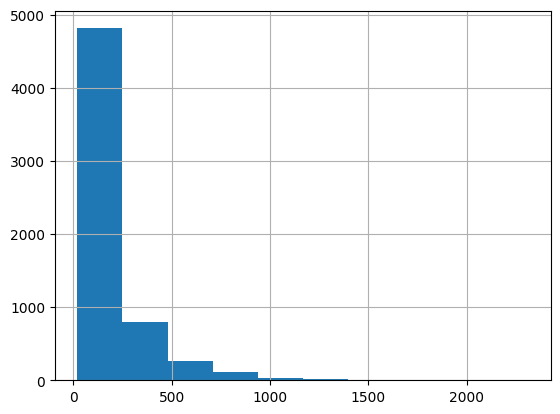

In [13]:
interactions_per_user = ratings.groupby("user_id").size()
print(interactions_per_user.describe())
print(interactions_per_user.hist())

### BUILD INTERACTION MATRIX WITH TRAIN DATA


In [ ]:
def user_item_interaction_matrix(data,user_col_name,item_col_name,pref_col_name):
    num_users=len(data[user_col_name].unique())
    num_items=len(data[item_col_name].unique())

    user_sort=sorted(data[user_col_name].unique())
    item_sort=sorted(data[item_col_name].unique())

    item_index,user_index={},{}
    
    for idx in range(len(user_sort)):
        user_index[user_sort[idx]]=idx
        
    for idx in range(len(item_sort)):
        item_index[item_sort[idx]]=idx
    
    # print(item_index,user_index)
    pref_matrix=np.zeros((num_users,num_items))
    
    for idx in range(len(data)):
        curr_user,curr_item,curr_pref=data[user_col_name].iloc[idx],data[item_col_name].iloc[idx],data[pref_col_name].iloc[idx]
        curr_user_idx,curr_item_idx=user_index[curr_user],item_index[curr_item]
        pref_matrix[curr_user_idx][curr_item_idx]=curr_pref
            
    return pref_matrix,user_index,item_index
        
pref_mat,user_index,item_index=user_item_interaction_matrix(train,"user_id","movie_id","rating")


In [46]:
U,S,Vt=np.linalg.svd(pref_mat)

In [ ]:
K=800
U_k=U[:,:K]
S_k=S[:K]
Vtk_T=Vt[:K,:]
S_sqrt=np.pow(S_k,0.5)
user_embedding=U_k*S_sqrt
item_embedding=Vtk_T.T*S_sqrt

In [89]:
R_approx = user_embedding @ item_embedding.T 
np.sum(R_approx-pref_mat)

np.float64(-587.1046229783353)

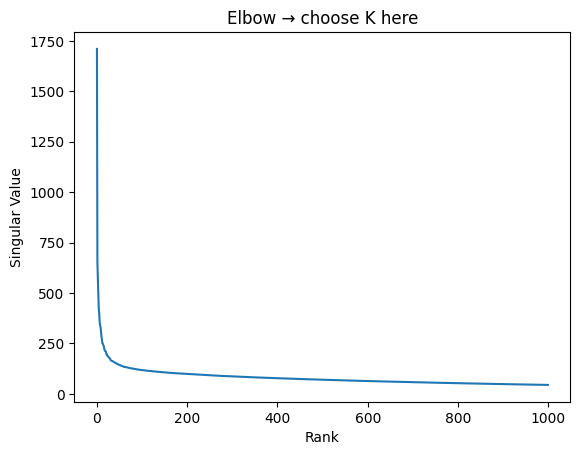

In [90]:
# Check singular value dropoff first
import matplotlib.pyplot as plt

plt.plot(S[:1000])
plt.xlabel("Rank")
plt.ylabel("Singular Value")
plt.title("Elbow → choose K here")
plt.show()

# Then pick K at the elbow
# K = 50  # start small, tune this!

# U  = U[:, :K]
# S  = S[:K]
# Vt = Vt[:K, :]

# S_sqrt = np.pow(S, 0.5)
# user_embedding = U * S_sqrt
# item_embedding = Vt.T * S_sqrt

(3666,)


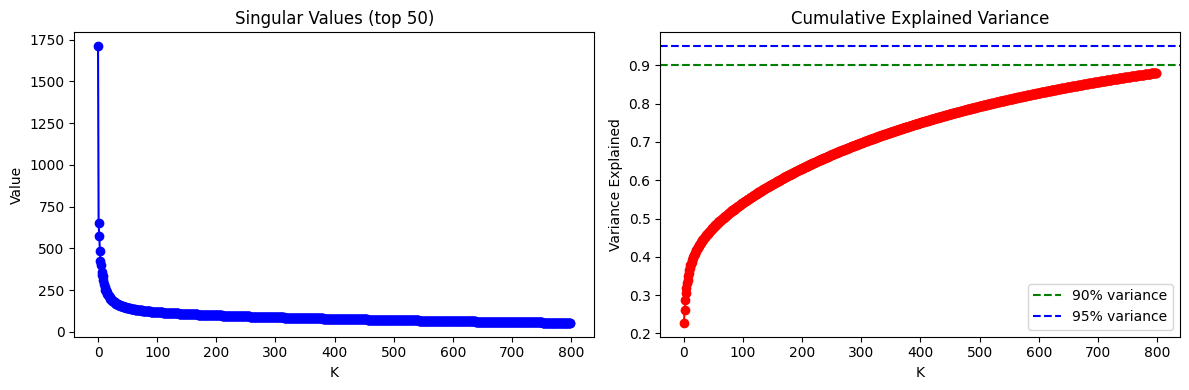

K for 90% variance: 895
K for 95% variance: 1260


In [91]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Raw values
print(S.shape)
K=800
ax1.plot(S[:K], 'bo-')
ax1.set_title("Singular Values (top 50)")
ax1.set_xlabel("K")
ax1.set_ylabel("Value")

# Explained variance (cumulative)
explained = np.cumsum(S**2) / np.sum(S**2)
ax2.plot(explained[:K], 'ro-')
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
ax2.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
ax2.set_title("Cumulative Explained Variance")
ax2.set_xlabel("K")
ax2.set_ylabel("Variance Explained")
ax2.legend()

plt.tight_layout()
plt.show()

# Find K for 90% and 95% variance
k_90 = np.argmax(explained >= 0.90) + 1
k_95 = np.argmax(explained >= 0.95) + 1
print(f"K for 90% variance: {k_90}")
print(f"K for 95% variance: {k_95}")

In [92]:
def evaluate(test_data, user_embedding, item_embedding, user_index, item_index,
             user_col="user_id", item_col="movie_id", rating_col="rating"):
    
    preds, actuals = [], []
    skipped = 0

    for _, row in test_data.iterrows():
        user_id = row[user_col]
        item_id = row[item_col]
        actual  = row[rating_col]

        # ── Skip if user or item not seen in train ──────────
        if user_id not in user_index or item_id not in item_index:
            skipped += 1
            continue  # cold start problem

        # ── Map original ID → matrix index ──────────────────
        u_idx = user_index[user_id]   # e.g. user_id=25  → row 18 in matrix
        i_idx = item_index[item_id]   # e.g. movie_id=50 → col 32 in matrix

        # ── Predict via dot product ──────────────────────────
        pred = user_embedding[u_idx] @ item_embedding[i_idx]

        preds.append(pred)
        actuals.append(actual)

    preds   = np.array(preds)
    actuals = np.array(actuals)

    # ── Metrics ──────────────────────────────────────────────
    rmse = np.sqrt(np.mean((preds - actuals) ** 2))
    mae  = np.mean(np.abs(preds - actuals))

    print(f"RMSE   : {rmse:.4f}")
    print(f"MAE    : {mae:.4f}")
    print(f"Skipped: {skipped} (cold start users/items)")

    return rmse, mae

# ── Usage ─────────────────────────────────────────────────────
rmse, mae = evaluate(test, user_embedding, item_embedding, user_index, item_index)

RMSE   : 3.6545
MAE    : 3.4437
Skipped: 4 (cold start users/items)


In [93]:
U.shape,S.shape,Vt.shape

((6040, 6040), (3666,), (3666, 3666))

In [94]:
len(train["movie_id"].unique())

3666